In [1]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive
import pickle
import warnings
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)


In [3]:
# Celda 3 — Función de evaluación (5-Fold CV, scaler por fold)
def evaluar_modelo_cv(model, X_train, y_train, X_val, y_val, X_test, y_test,
                      nombre, k=5):
    """
    Entrena modelo con K-Fold CV sobre train. Scaler se ajusta
    dentro de cada fold para evitar leakage. Reporta AUC-ROC/F1/Accuracy
    con intervalos de confianza (media ± 2σ) en train CV, val y test.
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])
        model.fit(X_tr_fold, y_train[tr_idx])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    model.fit(X_train_sc, y_train)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds),
        "AUC_CV_std":  np.std(auc_folds),
        "F1_CV_mean":  np.mean(f1_folds),
        "F1_CV_std":   np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds),
        "Acc_CV_std":  np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds),
        "Precision_CV_std":  np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds),
        "Recall_CV_std":  np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler,
        "_model": model,
    }


def tabla_resultados(resultados_lista):
    """Formatea lista de resultados como DataFrame con IC."""
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando Random Forest...
NOTA: Random Forest no requiere scaling (árboles son invariantes a escala).
  n_est= 50, depth=5   : AUC val = 0.7524
  n_est= 50, depth=10  : AUC val = 0.7885
  n_est= 50, depth=20  : AUC val = 0.8069
  n_est= 50, depth=None: AUC val = 0.8030
  n_est=100, depth=5   : AUC val = 0.7534
  n_est=100, depth=10  : AUC val = 0.7894
  n_est=100, depth=20  : AUC val = 0.8108
  n_est=100, depth=None: AUC val = 0.8106
  n_est=200, depth=5   : AUC val = 0.7532
  n_est=200, depth=10  : AUC val = 0.7898
  n_est=200, depth=20  : AUC val = 0.8132
  n_est=200, depth=None: AUC val = 0.8141


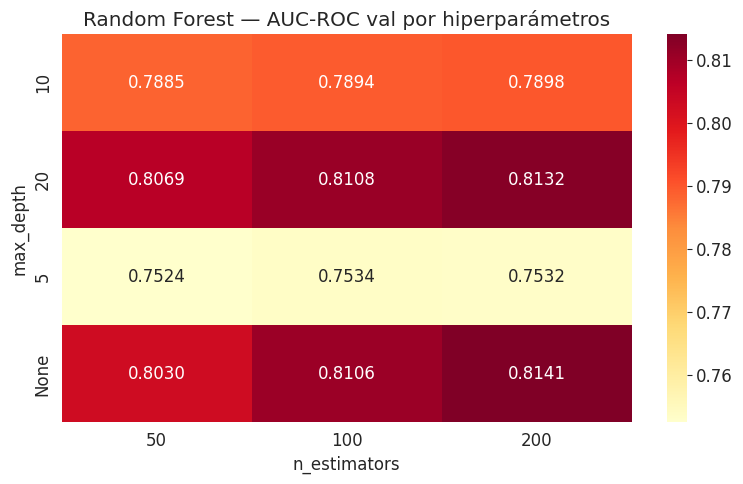


Mejores parámetros RF: {'n_estimators': 200, 'max_depth': None}


AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▁▅▇▇▁▅██▁▅███
Acc_test,▁
F1_test,▁
n_estimators,▁▁▁▁▃▃▃▃████
AUC_CV_2std,0.00329
AUC_CV_mean,0.80985
AUC_test,0.81164
AUC_val,0.81415


In [5]:
# Celda 4 — Random Forest (ensamble de árboles)
nombre_modelo = "Random Forest"

wandb.init(project="higgs-boson", name="Random Forest",config={"n_estimators_grid": [50, 100, 200], "max_depth_grid": [5, 10, 20, None]})
print(f"Entrenando {nombre_modelo}...")
print("NOTA: Random Forest no requiere scaling (árboles son invariantes a escala).")

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [5, 10, 20, None]
}
best_auc_rf = 0
best_params_rf = {}
rf_results_grid = []

for n_est in param_grid_rf["n_estimators"]:
    for depth in param_grid_rf["max_depth"]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth,
                                    random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
        rf_results_grid.append({"n_estimators": n_est, "max_depth": str(depth), "AUC": auc})
        wandb.log({"n_estimators": n_est, "max_depth": str(depth), "AUC_val": auc})
        print(f"  n_est={n_est:3d}, depth={str(depth):4s}: AUC val = {auc:.4f}")
        if auc > best_auc_rf:
            best_auc_rf = auc
            best_params_rf = {"n_estimators": n_est, "max_depth": depth}

df_rf_grid = pd.DataFrame(rf_results_grid)
pivot_rf = df_rf_grid.pivot(index="max_depth", columns="n_estimators", values="AUC")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_rf, annot=True, fmt=".4f", cmap="YlOrRd")
plt.title("Random Forest — AUC-ROC val por hiperparámetros")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_rf_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMejores parámetros RF: {best_params_rf}")
rf_best = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
result = evaluar_modelo_cv(rf_best, X_train, y_train, X_val, y_val,
                            X_test, y_test, nombre_modelo)

# Log final metrics to wandb
wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()


In [ ]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

# Guardar CSV para ensamblaje final
safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

# Guardar modelo pickle
with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

              AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                     
Random Forest    0.810 ± 0.003   0.814    0.812   0.751    0.734          0.746       0.757
